In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read dataset
# Change path to your downloaded CSV
df = pd.read_excel(r"c:\Users\franc\OneDrive\Documents\DSI\visualization\02_activities\assignments\pollinateto_locations.xlsx")       

In [35]:
# Inspect column names if needed
print(df.columns)

Index(['_id', 'ID', 'YEAR_FUNDED', 'GROUP_NAME', 'PROJECT_NAME', 'GARDEN_TYPE',
       'NUMBER_OF_GARDENS', 'ESTIMATED_GARDEN_SIZE', 'NEIGHBOURHOOD_NUMBER',
       'NIA_OR_EN', 'PRIMARY_LOCATION_NAME', 'PRIMARY_GARDEN_ADDRESS',
       'POSTAL_CODE', 'IS_INDIGENOUS_GARDEN', 'WARD_NAME', 'WARD_NUMBER',
       'DESCRIPTION', 'IMAGE_NAME', 'IMAGE_ALT_TEXT', 'geometry'],
      dtype='object')


In [ ]:
# ---------------------------------
# Consolidate simmilar garden types
# ---------------------------------

df["GARDEN_CATEGORY"] = ["Rain Garden" if "Rain Garden" in x  
                         else "City Park" if "City Park" in x 
                         else "School Learning Garden" if "School Learning Garden" in x 
                         else x for x in df["GARDEN_TYPE"]]

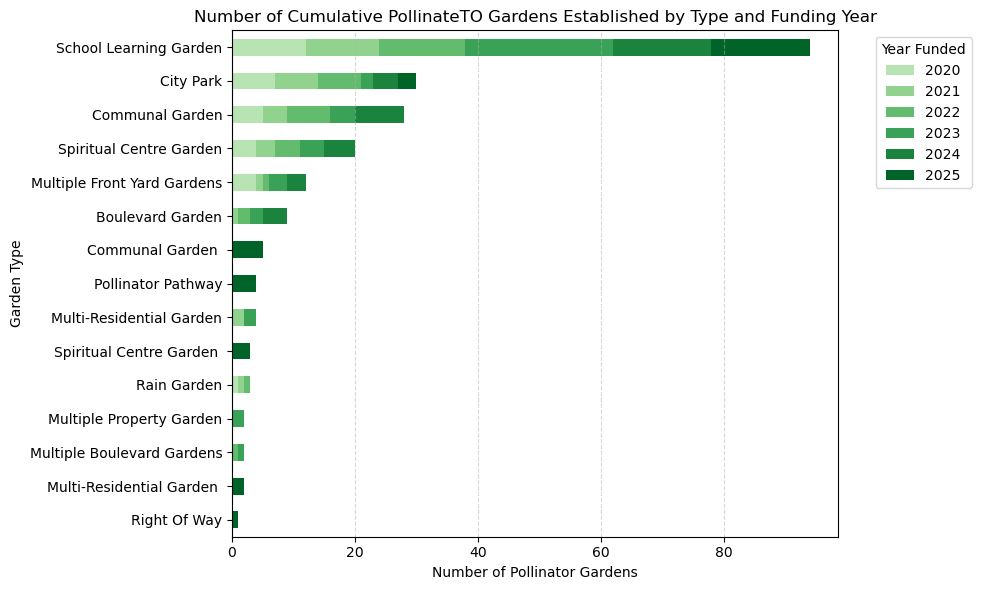

In [ ]:
# -----------------------
# Perform data cleansing
# -----------------------

# Remove missing values, if any
df_clean = df.dropna(subset=["GARDEN_CATEGORY", "YEAR_FUNDED"])

# Convert year to integer (optional)
df_clean["YEAR_FUNDED"] = df_clean["YEAR_FUNDED"].astype(int)

# Count gardens by type and year
garden_counts = (
    df_clean
    .groupby(["GARDEN_CATEGORY", "YEAR_FUNDED"])
    .size()
    .reset_index(name="Number of Pollinator Gardens")
)

# Convert to wide format for stacked plotting
pivot_table = (
    garden_counts
    .pivot(
        index="GARDEN_CATEGORY",
        columns="YEAR_FUNDED",
        values="Number of Pollinator Gardens"
    )
    .fillna(0)
)

# Sort by total number of gardens
pivot_table = pivot_table.loc[
    pivot_table.sum(axis=1).sort_values().index
]


# -----------------------
# Create stacked bar plot
# -----------------------

# Create green sequential colors based on number of years
colors = plt.cm.Greens(
    np.linspace(0.3, 0.9, len(pivot_table.columns))
)

fig, ax = plt.subplots(figsize=(10, 6))

pivot_table.plot(
    kind="barh",
    stacked=True,
    color=colors,
    ax=ax
)

# Labels and formatting
ax.set_xlabel("Number of Pollinator Gardens")
ax.set_ylabel("Garden Type")

ax.set_title(
    "Number of Cumulative PollinateTO Gardens Established by Type and Funding Year"
)

ax.legend(
    title="Year Funded",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Add grid
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()